# EXPLORE REGIONS

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import signal
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid", font_scale=1.2)    

day_region_df  = pd.read_csv("../data/long_daily_scaledPer10k.csv")
week_region_df = pd.read_csv("../data/long_weekly_scaledPer10k.csv")

week_region_df.columns

Index(['Region', 'Date', 'Value'], dtype='object')

## Time Series

### Daily

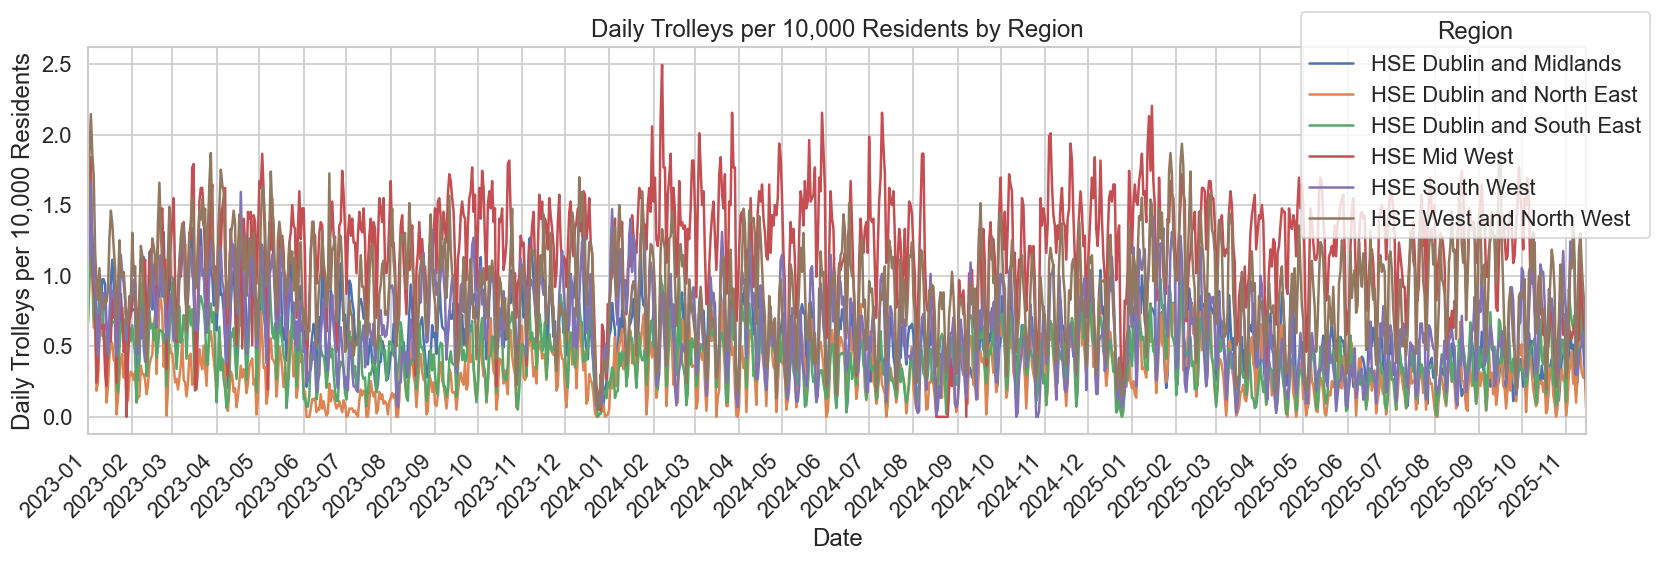

In [68]:
# make sure the date column is datetime
day_region_df['Date'] = pd.to_datetime(day_region_df['Date'])

plt.figure(figsize=(14, 5), dpi=120)
ax = sns.lineplot(data=day_region_df, x='Date', y='Value', hue='Region')
ax.set_title("Daily Trolleys per 10,000 Residents by Region")

ax.set_xlim(day_region_df['Date'].min(), day_region_df['Date'].max())

# make the dates sparse – major tick once a month (or adjust interval)
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_xlabel('Date')
ax.set_ylabel('Daily Trolleys per 10,000 Residents')

ax.legend(title='Region', bbox_to_anchor=(1.05, 1.12), loc='upper right')
plt.tight_layout()

#### Zoomed on new year

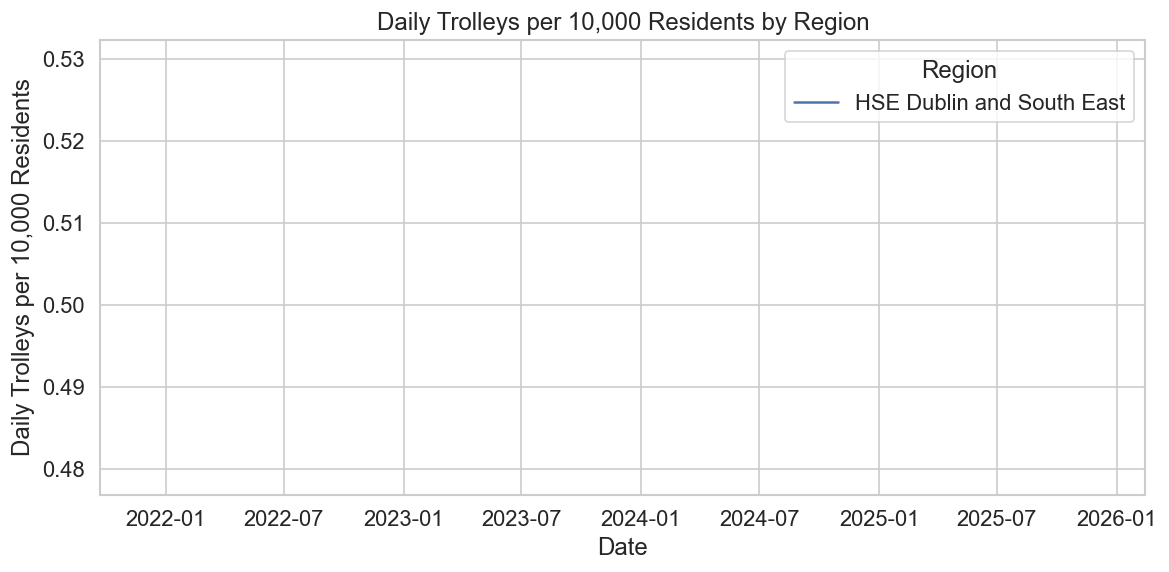

In [69]:
plt.figure(figsize=(10, 5),dpi=120)

df_filtered = day_region_df.truncate(before='2023-12-01', after='2024-01-30')

ax=sns.lineplot(data=df_filtered, x='Date', y='Value', hue='Region')
ax.set_title("Daily Trolleys per 10,000 Residents by Region")

ax.set_xlabel('Date')
ax.set_ylabel('Daily Trolleys per 10,000 Residents')

ax.legend(title='Region', loc='upper right')
plt.tight_layout()

In [70]:
df_filtered

,Unnamed: 0,Date,Region,Value
2024,2024,2023-12-04,HSE Dublin and South East,0.504586


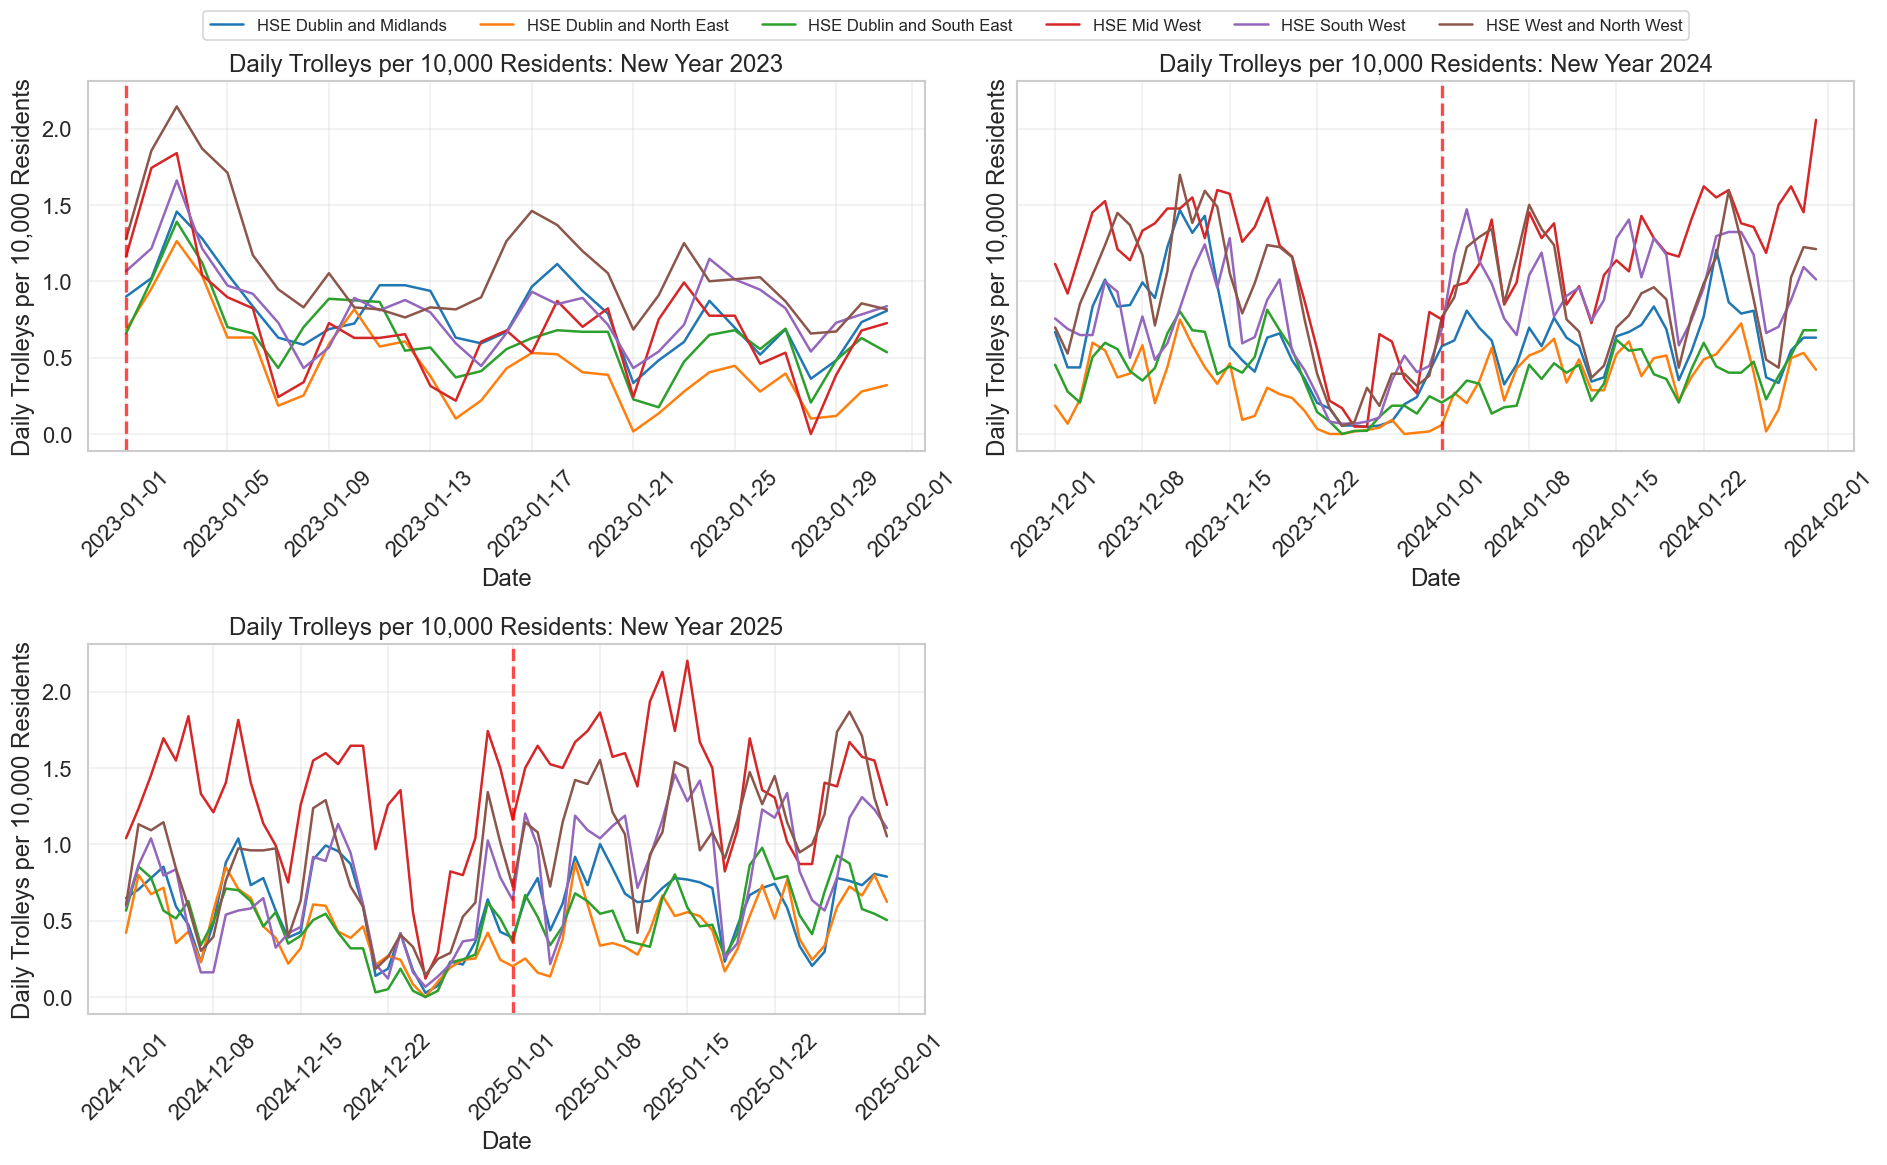

In [71]:
# Get all unique years in the data and create subplots for each New Year
day_region_df['Date'] = pd.to_datetime(day_region_df['Date'])
years_in_data = day_region_df['Date'].dt.year.unique()
new_years = sorted(years_in_data)

# Calculate number of rows needed for 2-column layout
n_plots = len(new_years)
n_rows = (n_plots + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows), dpi=120, sharey=True)
if n_rows == 1: axes = axes.reshape(1, -1)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Get all unique regions for single legend
all_regions = sorted(day_region_df['Region'].unique())
colors = plt.cm.tab10(range(len(all_regions)))
region_colors = {region: colors[i] for i, region in enumerate(all_regions)}

for idx, year in enumerate(new_years):
    ax = axes_flat[idx]
    
    # Create date range: 1 month before to 1 month after Jan 1
    start_date = pd.Timestamp(f'{year-1}-12-01')
    end_date = pd.Timestamp(f'{year}-01-31')
    
    df_filtered = day_region_df[(day_region_df['Date'] >= start_date) & 
                                (day_region_df['Date'] <= end_date)]
    
    # Use matplotlib directly instead of seaborn
    for region in all_regions:
        region_data = df_filtered[df_filtered['Region'] == region]
        ax.plot(region_data['Date'], region_data['Value'], label=region, 
                linewidth=1.5, color=region_colors[region])
    
    ax.set_title(f"Daily Trolleys per 10,000 Residents: New Year {year}")
    ax.set_xlabel('Date')
    ax.set_ylabel('Daily Trolleys per 10,000 Residents')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # Add vertical line at New Year
    ax.axvline(x=pd.Timestamp(f'{year}-01-01'), color='red', linestyle='--', alpha=0.7, linewidth=2)

# Hide any unused subplots
for idx in range(n_plots, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Create single legend at the top
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=6, bbox_to_anchor=(0.5, 0.98), 
           frameon=True, fontsize=10)


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Weekly

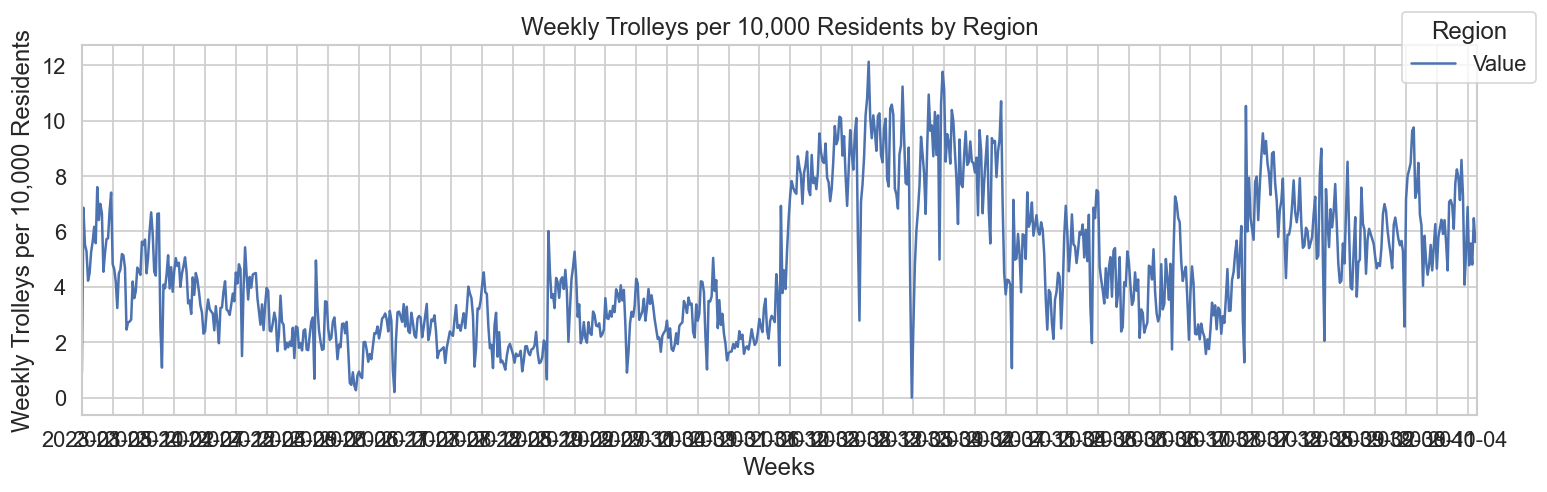

In [72]:
plt.figure(figsize=(15,4),dpi=120)
ax=sns.lineplot(data=week_region_df)
ax.set_xlim(0, week_region_df.shape[0])
ax.set_title("Weekly Trolleys per 10,000 Residents by Region")

# Set x-ticks and labels
ax.set_xticks(week_region_df.index[::20])
x_labels = pd.to_datetime('2023-01-01') + pd.to_timedelta(week_region_df.index, unit='W')
x_labels = x_labels.strftime('%Y-%m')
ax.set_xticklabels(x_labels[::20])

ax.set_xlabel('Weeks')
ax.set_ylabel('Weekly Trolleys per 10,000 Residents')

ax.legend(title='Region', bbox_to_anchor=(1.05, 1.12), loc='upper right')

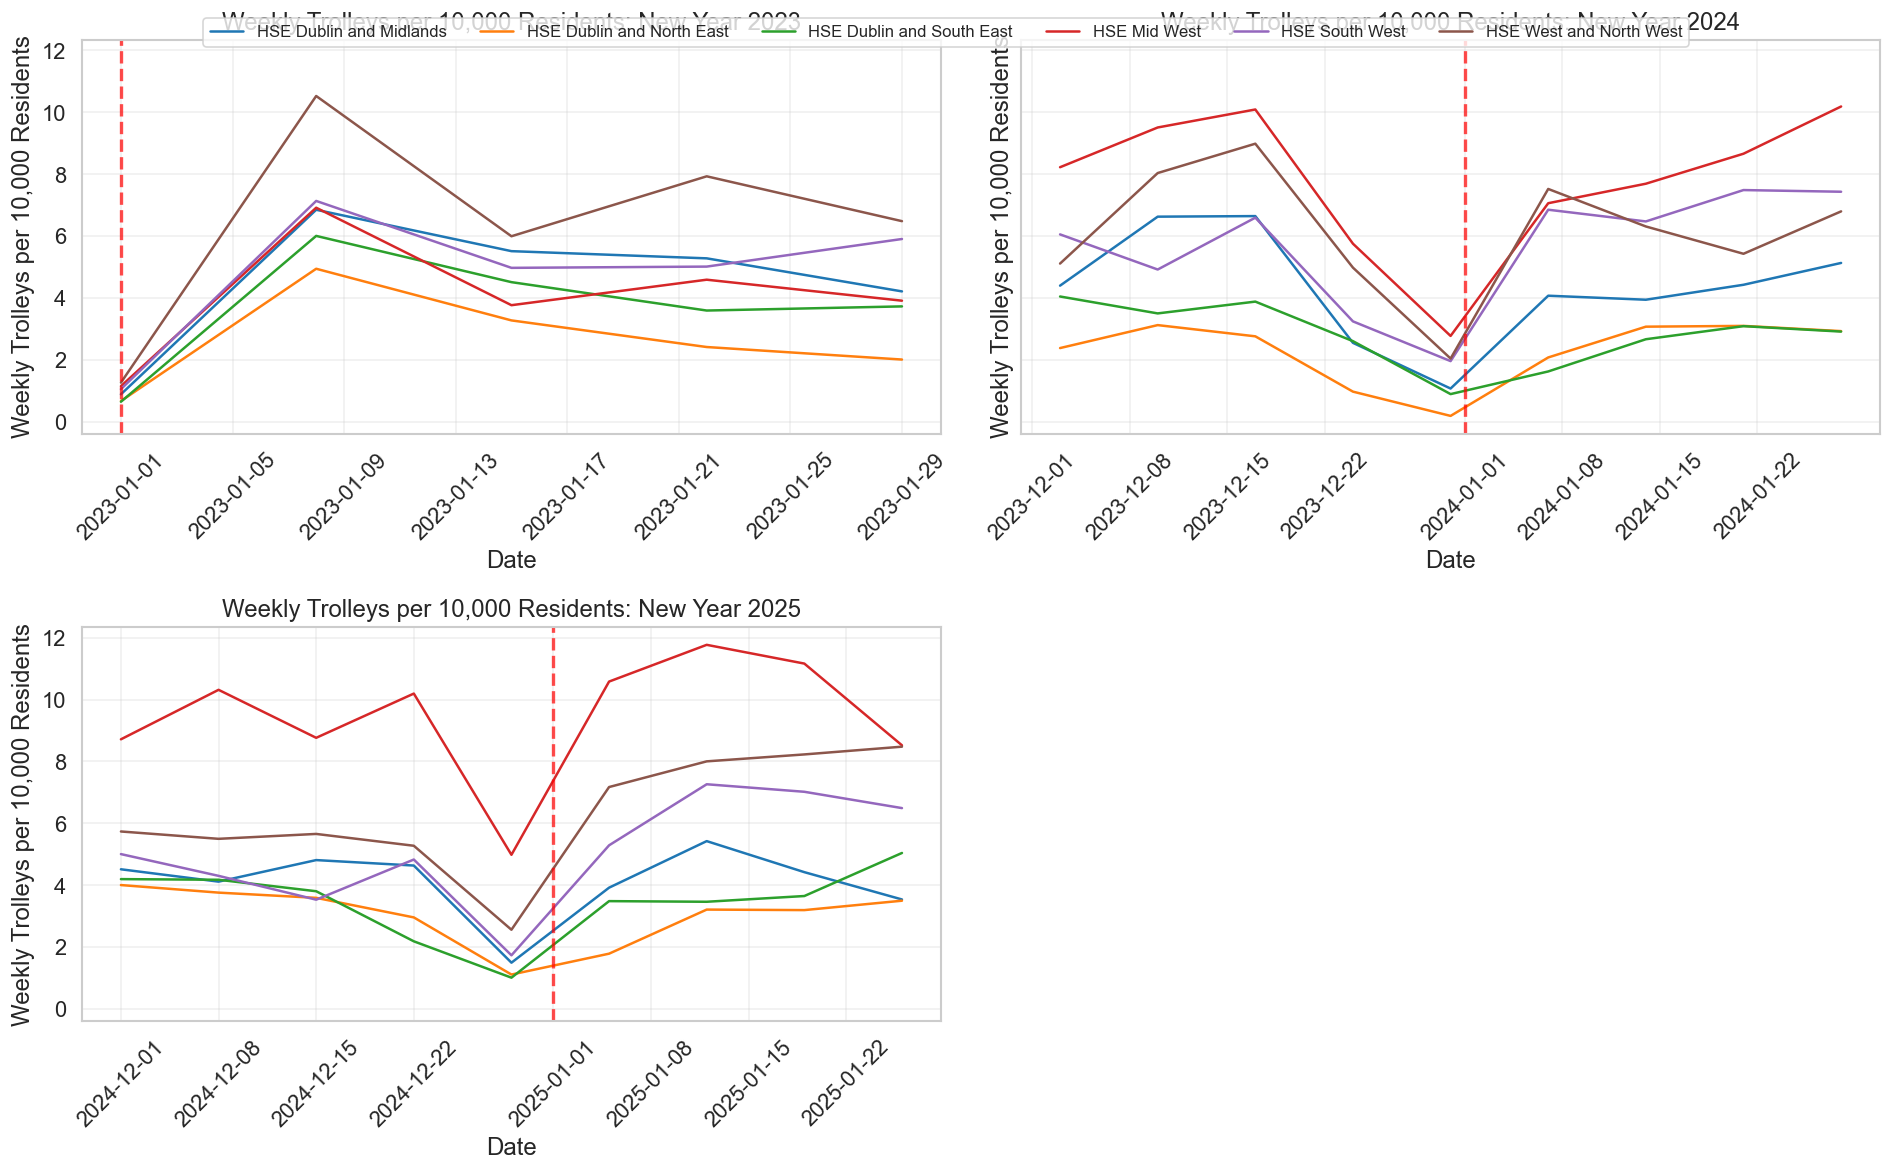

In [73]:
# Get all unique years in the data and create subplots for each New Year

week_region_df['Date'] = pd.to_datetime(week_region_df['Date'])
years_in_data = week_region_df['Date'].dt.year.unique()
new_years = sorted(years_in_data)

# Calculate number of rows needed for 2-column layout
n_plots = len(new_years)
n_rows = (n_plots + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows), dpi=120, sharey=True)
if n_rows == 1: axes = axes.reshape(1, -1)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Get all unique regions for single legend
all_regions = sorted(week_region_df['Region'].unique())
colors = plt.cm.tab10(range(len(all_regions)))
region_colors = {region: colors[i] for i, region in enumerate(all_regions)}

for idx, year in enumerate(new_years):
    ax = axes_flat[idx]
    
    # Create date range: 1 month before to 1 month after Jan 1
    start_date = pd.Timestamp(f'{year-1}-12-01')
    end_date = pd.Timestamp(f'{year}-01-31')
    
    df_filtered = week_region_df[(week_region_df['Date'] >= start_date) & 
                                (week_region_df['Date'] <= end_date)]
    
    # Use matplotlib directly instead of seaborn
    for region in all_regions:
        region_data = df_filtered[df_filtered['Region'] == region]
        ax.plot(region_data['Date'], region_data['Value'], label=region, 
                linewidth=1.5, color=region_colors[region])
    
    ax.set_title(f"Weekly Trolleys per 10,000 Residents: New Year {year}")
    ax.set_xlabel('Date')
    ax.set_ylabel('Weekly Trolleys per 10,000 Residents')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # Add vertical line at New Year
    ax.axvline(x=pd.Timestamp(f'{year}-01-01'), color='red', linestyle='--', alpha=0.7, linewidth=2)

# Hide any unused subplots
for idx in range(n_plots, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Create single legend at the top
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=6, bbox_to_anchor=(0.5, 0.98), 
           frameon=True, fontsize=10)


plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

## Week day effects
Plotting mean for each weekday

### Weekday means

Text(0, 0.5, 'Mean Trolleys per 10,000 Residents')

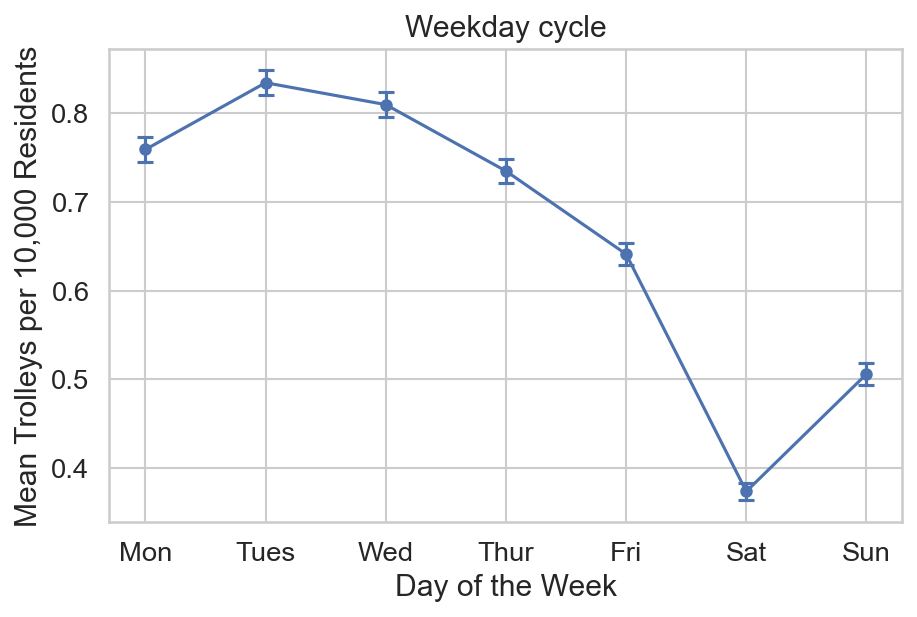

In [74]:
day_region_df['weekday']= day_region_df['Date'].dt.dayofweek

grouped = day_region_df.groupby('weekday')['Value']
means = grouped.mean()
sems = grouped.sem()

plt.figure(figsize=(6, 4), dpi=150, layout='constrained')
plt.errorbar(means.index, means.values, yerr=sems.values,
             fmt='o-', capsize=4, capthick=1.5, linewidth=1.5, markersize=5)
plt.xticks(range(7), ["Mon", "Tues", "Wed", "Thur", "Fri", "Sat", "Sun"])
plt.title("Weekday cycle")
plt.xlabel("Day of the Week")
plt.ylabel("Mean Trolleys per 10,000 Residents")

# Autocorrelations

### Daily

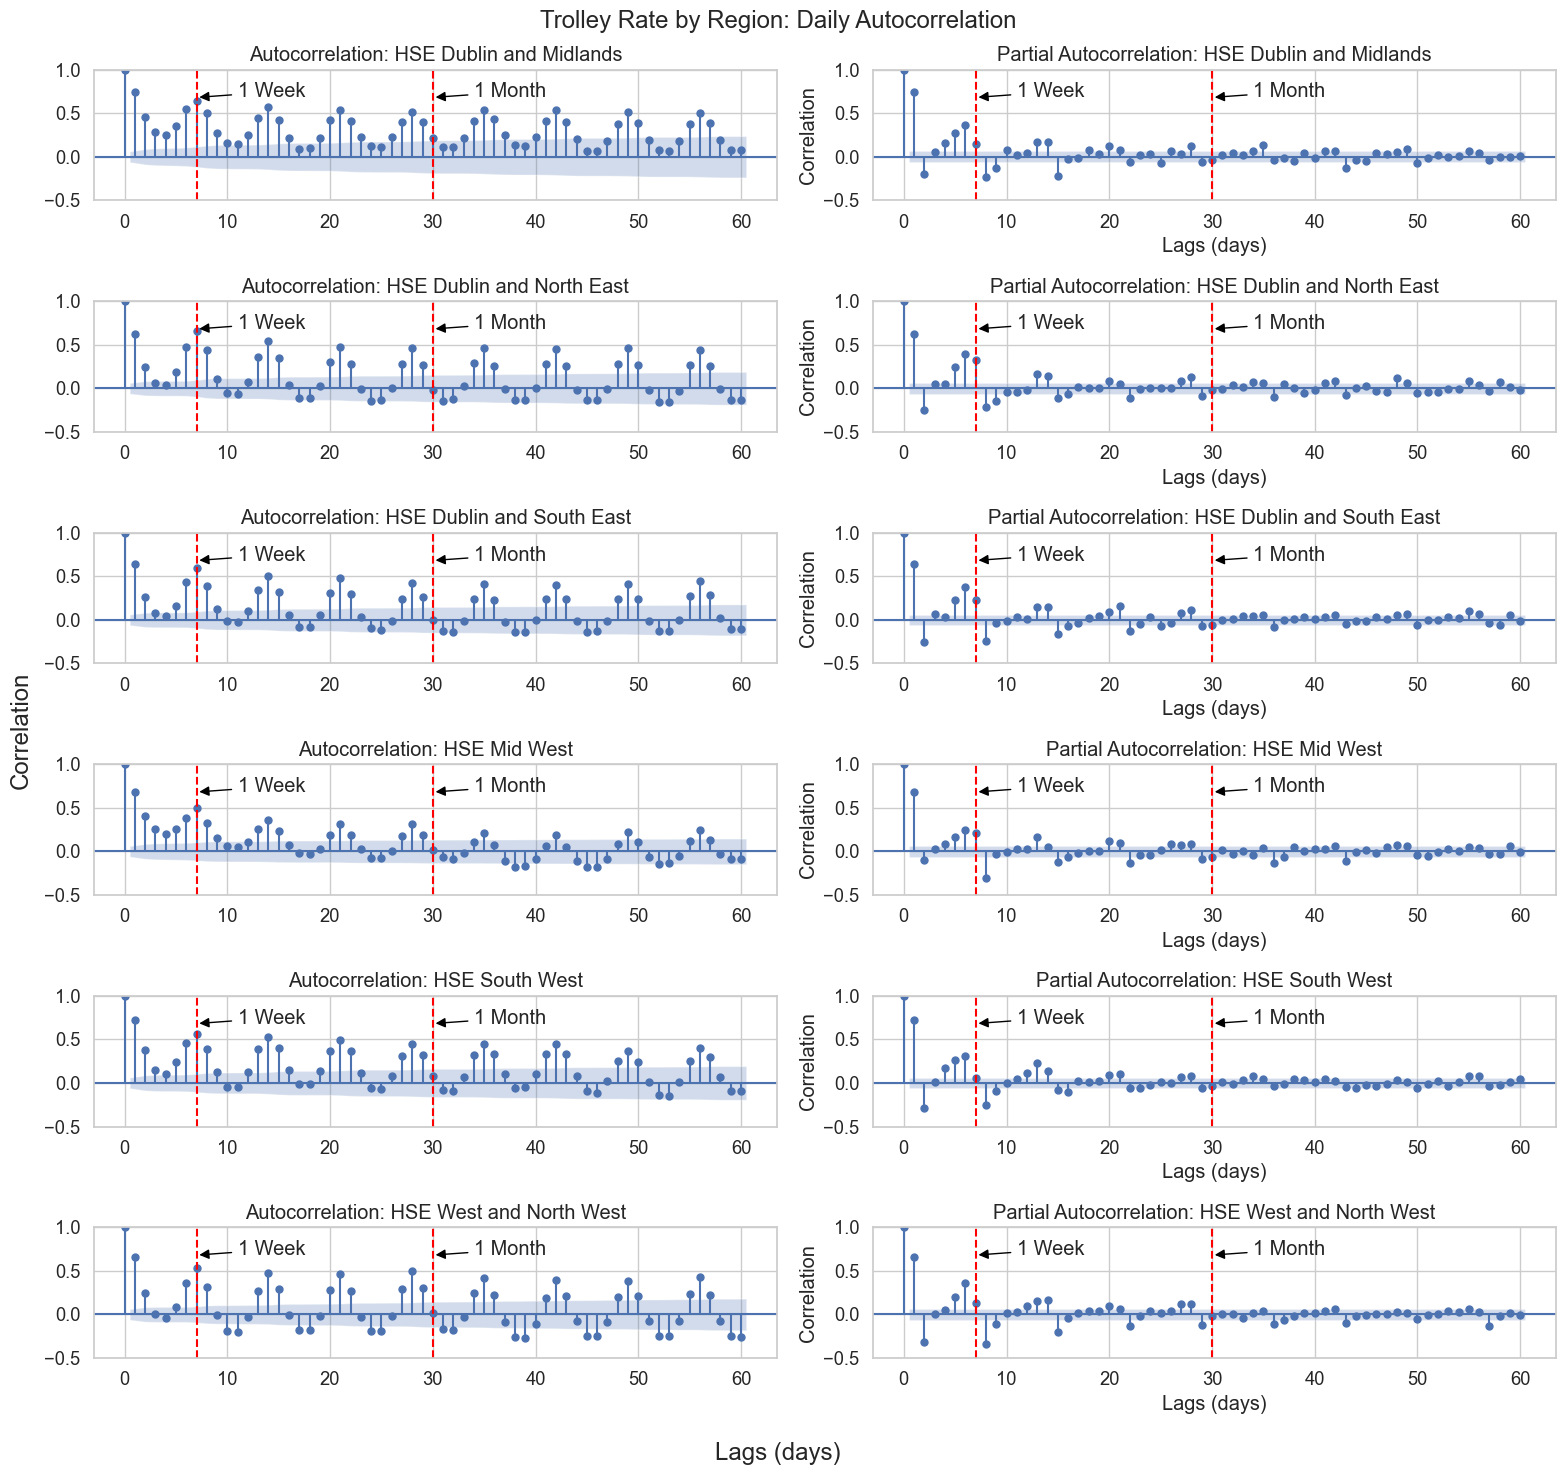

In [75]:
# settings
y_loc=.68; x_shift=4
n_lags=60

daily_wide = day_region_df.pivot(index='Date', columns='Region', values='Value')

fig, axes = plt.subplots(daily_wide.columns.__len__(), 2, figsize=(16, 15))#, sharey=True)
for i, (ax, col) in enumerate(zip(axes, daily_wide.columns)):

    plot_acf(daily_wide[col],  lags=n_lags, ax=ax[0], title=f'Autocorrelation: {col}')
    plot_pacf(daily_wide[col], lags=n_lags, ax=ax[1], title=f'Partial Autocorrelation: {col}')

    # annotation lines
    ax[0].axvline(x=7, color='red', linestyle='--')  
    ax[0].axvline(x=30, color='red', linestyle='--') 
    ax[1].axvline(x=7, color='red', linestyle='--')  
    ax[1].axvline(x=30, color='red', linestyle='--') 
    # annotation text
    ax[0].annotate('1 Week',   xy=(7, plt.ylim()[1]*y_loc), xytext=(7  +x_shift, plt.ylim()[1]*y_loc), arrowprops=dict(arrowstyle='-|>', color='black'))
    ax[0].annotate('1 Month',  xy=(30,plt.ylim()[1]*y_loc), xytext=(30 +x_shift, plt.ylim()[1]*y_loc),  arrowprops=dict(arrowstyle='-|>', color='black'))
    ax[1].annotate('1 Week',   xy=(7, plt.ylim()[1]*y_loc), xytext=(7  +x_shift, plt.ylim()[1]*y_loc), arrowprops=dict(arrowstyle='-|>', color='black'))
    ax[1].annotate('1 Month',  xy=(30,plt.ylim()[1]*y_loc), xytext=(30 +x_shift, plt.ylim()[1]*y_loc),  arrowprops=dict(arrowstyle='-|>', color='black'))

    ax[0].set_ylim(-.5,1)
    ax[1].set_ylim(-.5,1)

    ax[1].set_ylabel('Correlation')
    ax[1].set_xlabel('Lags (days)')

fig.suptitle('Trolley Rate by Region: Daily Autocorrelation')
fig.supxlabel('Lags (days)')
fig.supylabel('Correlation')
plt.tight_layout()

## Weekly Autocorrelation

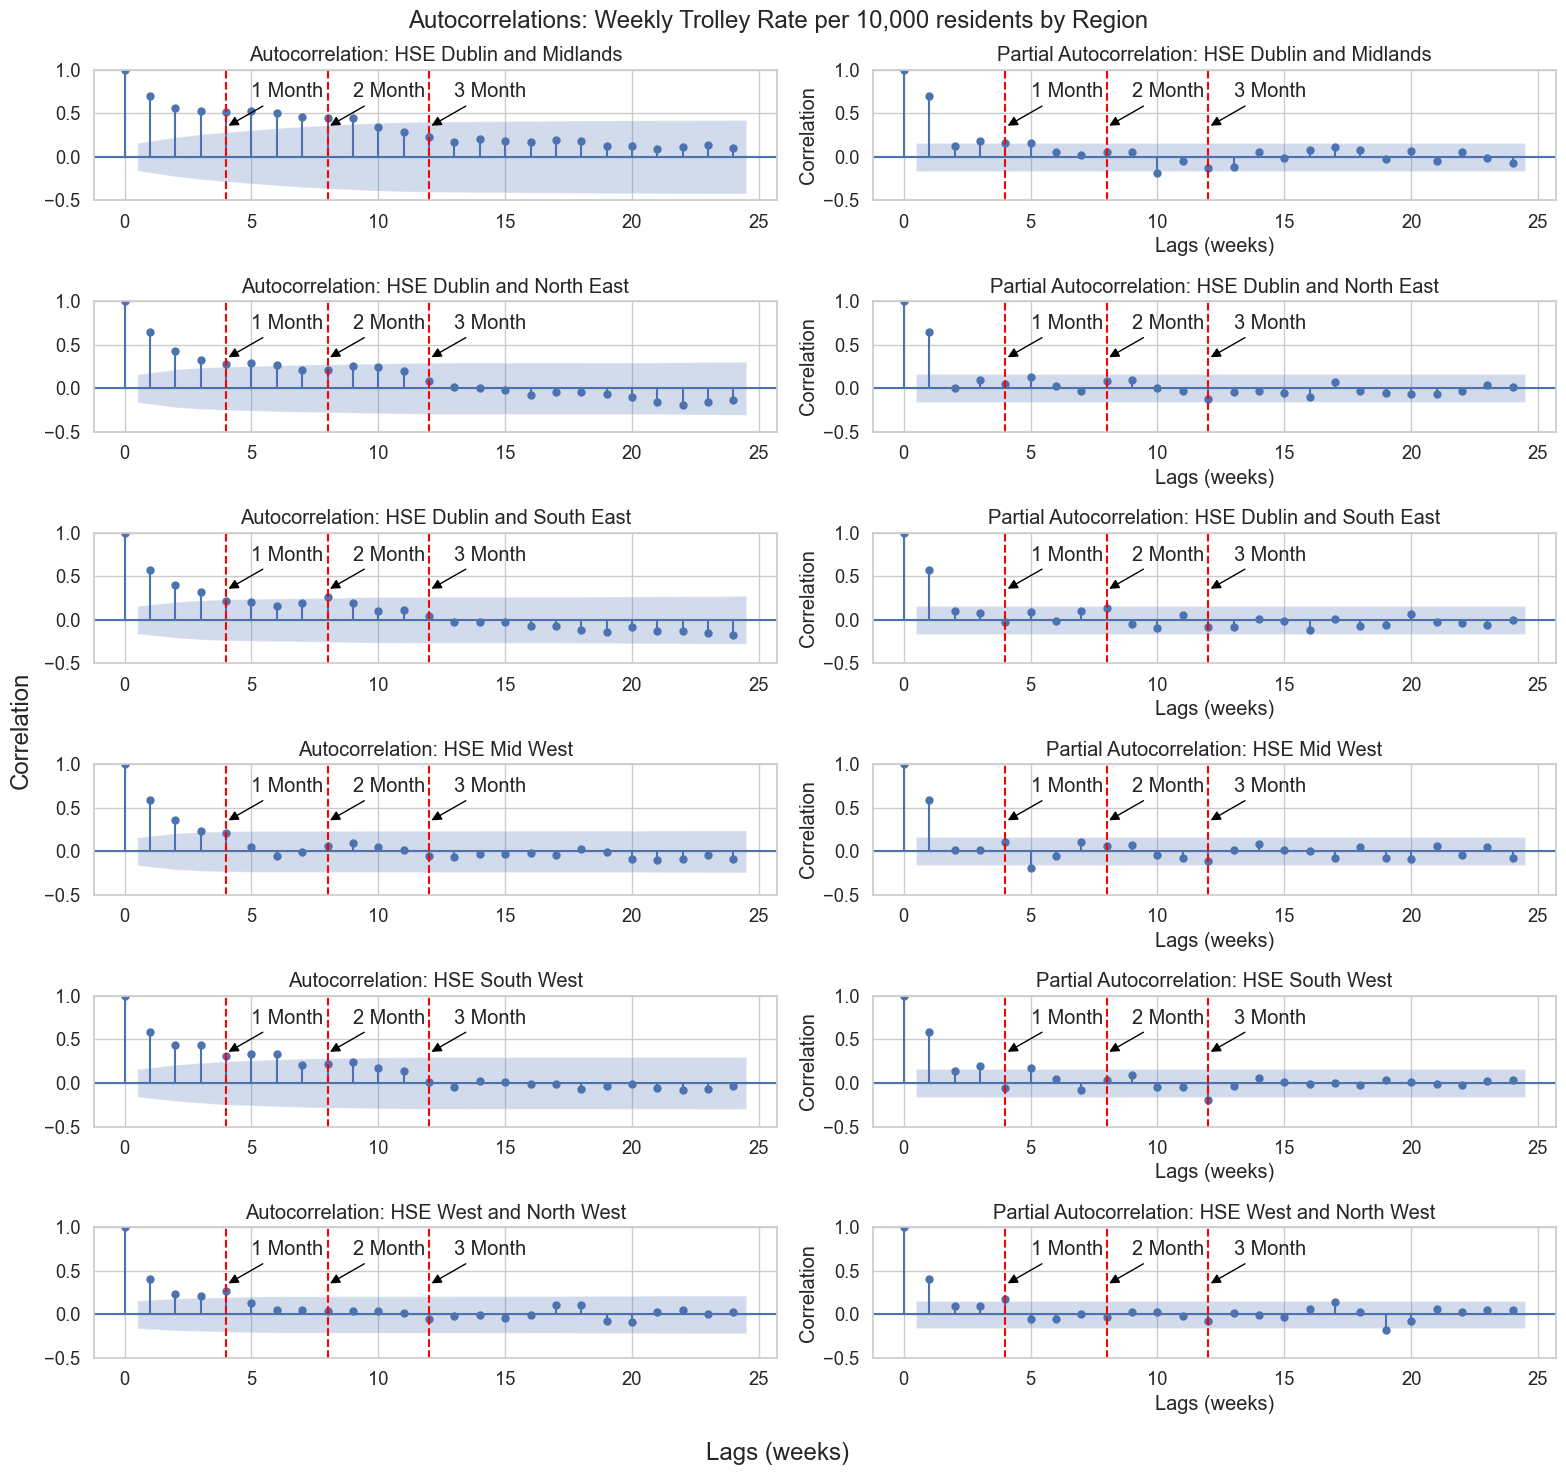

In [76]:
# settings
y_loc=.68; x_shift=1; n_lags=24

weekly_wide = week_region_df.pivot(index='Date', columns='Region', values='Value')

fig, axes = plt.subplots(weekly_wide.columns.__len__(), 2, figsize=(16, 15))#, sharey=True)
for i, (ax, col) in enumerate(zip(axes, weekly_wide.columns)):

    plot_acf(weekly_wide[col],  lags=n_lags, ax=ax[0], title=f'Autocorrelation: {col}')
    plot_pacf(weekly_wide[col], lags=n_lags, ax=ax[1], title=f'Partial Autocorrelation: {col}')

    # annotation lines
    ax[0].axvline(x=4, color='red', linestyle='--')  
    ax[1].axvline(x=4, color='red', linestyle='--')  
    ax[0].axvline(x=8, color='red', linestyle='--')
    ax[1].axvline(x=8, color='red', linestyle='--')  
    ax[0].axvline(x=12, color='red', linestyle='--')
    ax[1].axvline(x=12, color='red', linestyle='--')
    # annotation text
    ax[0].annotate('1 Month', xy=(4,  plt.ylim()[1]*y_loc*.5), xytext=(4 +x_shift,  plt.ylim()[1]*y_loc), arrowprops=dict(arrowstyle='-|>', color='black'))
    ax[1].annotate('1 Month', xy=(4,  plt.ylim()[1]*y_loc*.5), xytext=(4 +x_shift,  plt.ylim()[1]*y_loc), arrowprops=dict(arrowstyle='-|>', color='black'))
    ax[0].annotate('2 Month', xy=(8,  plt.ylim()[1]*y_loc*.5), xytext=(8 +x_shift,  plt.ylim()[1]*y_loc), arrowprops=dict(arrowstyle='-|>', color='black'))
    ax[1].annotate('2 Month', xy=(8,  plt.ylim()[1]*y_loc*.5), xytext=(8 +x_shift,  plt.ylim()[1]*y_loc), arrowprops=dict(arrowstyle='-|>', color='black'))
    ax[0].annotate('3 Month', xy=(12, plt.ylim()[1]*y_loc*.5), xytext=(12 +x_shift, plt.ylim()[1]*y_loc), arrowprops=dict(arrowstyle='-|>', color='black'))
    ax[1].annotate('3 Month', xy=(12, plt.ylim()[1]*y_loc*.5), xytext=(12 +x_shift, plt.ylim()[1]*y_loc), arrowprops=dict(arrowstyle='-|>', color='black'))

    ax[0].set_ylim(-.5,1)
    ax[1].set_ylim(-.5,1)

    ax[1].set_ylabel('Correlation')
    ax[1].set_xlabel('Lags (weeks)')
    
fig.suptitle('Autocorrelations: Weekly Trolley Rate per 10,000 residents by Region')
fig.supxlabel('Lags (weeks)')
fig.supylabel('Correlation')
plt.tight_layout()

### Example: HSE Dublin and Midlands — PACF & Power Spectral Density

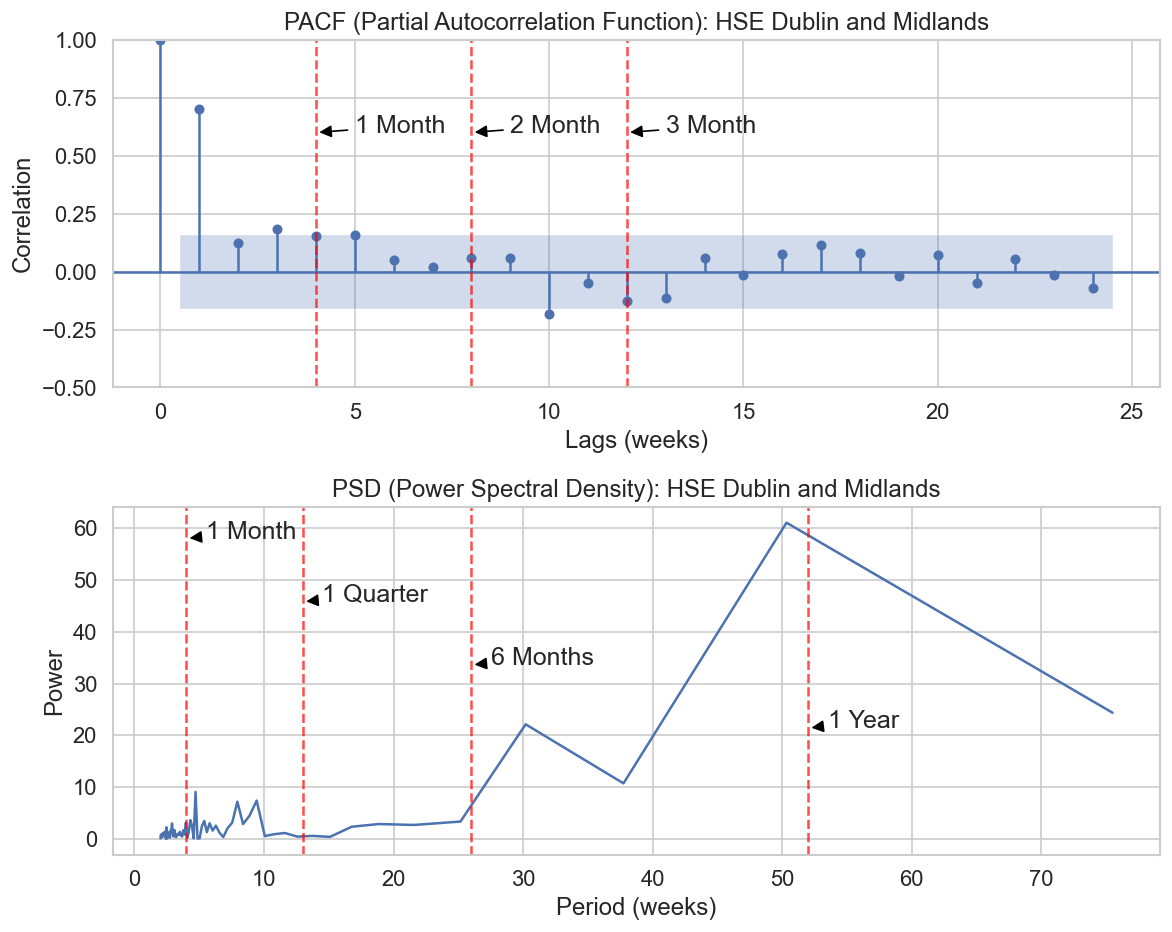

In [79]:
from scipy.signal import periodogram

region = 'HSE Dublin and Midlands'
series = weekly_wide[region].dropna()
font_size = 15
fig, axes = plt.subplots(2, 1, figsize=(10, 8), dpi=120)

# PACF (top)
plot_pacf(series, lags=24, ax=axes[0], title=f'PACF (Partial Autocorrelation Function): {region}')
axes[0].axvline(x=4,  color='red', linestyle='--', alpha=0.7)
axes[0].axvline(x=8,  color='red', linestyle='--', alpha=0.7)
axes[0].axvline(x=12, color='red', linestyle='--', alpha=0.7)
axes[0].annotate('1 Month', xy=(4,  0.6), xytext=(5,  0.6), arrowprops=dict(arrowstyle='-|>', color='black'), fontsize=font_size)
axes[0].annotate('2 Month', xy=(8,  0.6), xytext=(9,  0.6), arrowprops=dict(arrowstyle='-|>', color='black'), fontsize=font_size)
axes[0].annotate('3 Month', xy=(12, 0.6), xytext=(13, 0.6), arrowprops=dict(arrowstyle='-|>', color='black'), fontsize=font_size)
axes[0].set_ylim(-0.5, 1)
axes[0].set_xlabel('Lags (weeks)')
axes[0].set_ylabel('Correlation')

# PSD (bottom)
freqs, power = periodogram(series, fs=1.0)
freqs_nz = freqs[1:]
power_nz = power[1:]
periods = 1 / freqs_nz

mask = periods <= 100
periods = periods[mask]
power_nz = power_nz[mask]

axes[1].plot(periods, power_nz, linewidth=1.5)
axes[1].set_title(f'PSD (Power Spectral Density): {region}')
axes[1].set_xlabel('Period (weeks)')
axes[1].set_ylabel('Power')

ymax = power_nz.max()
stagger = [0.95, 0.75, 0.55, 0.35]
for (p, label), height in zip([(4, '1 Month'), (13, '1 Quarter'), (26, '6 Months'), (52, '1 Year')], stagger):
    if p <= periods.max():
        axes[1].axvline(x=p, color='red', linestyle='--', alpha=0.7)
        axes[1].annotate(label, xy=(p, ymax * height), xytext=(p + 1.5, ymax * height),
                         arrowprops=dict(arrowstyle='-|>', color='black'), fontsize=font_size)

plt.tight_layout()
plt.show()